# Research notebook: XAUUSD Buy Win Probability

Notebook này dùng để nghiên cứu data, label, feature engineering và baseline model cho bài toán:

> Dự đoán `P(Win | Buy candidate, thông tin biết tại close của candle hiện tại)` trên XAUUSD M1.

Thiết kế theo hướng MLOps:

- Data contract rõ ràng: CSV M1 theo từng năm.
- Label contract rõ ràng: Buy tại next open, TP/SL theo config, chỉ label được nhìn tương lai.
- Feature engineering có audit/catalog/missing/drift checks.
- Split theo thời gian: train → validation → test.
- Model output là xác suất Win, đánh giá bằng AUC, Average Precision, LogLoss, Brier, calibration.
- Cache build theo từng năm để tránh tràn RAM.
- Lưu artifacts: config, metrics, feature list, model bundle, threshold tables.

## 1. Parameters

In [1]:
from __future__ import annotations

RUN_FULL_RESEARCH = False
FORCE_YEAR_CACHE = False
SAVE_ARTIFACTS = True
ENABLE_MLFLOW = False

YEARS_TO_BUILD = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
FAST_YEARS = [2022, 2023, 2024]
MAX_RAW_ROWS_PER_YEAR = None

FEATURE_SET_NAME = "fs14_bb_overlay_norm_behavior"
MODEL_KIND = "lightgbm"  # "lightgbm" hoặc "random_forest"
MAX_TRAIN_ROWS = 500_000
RANDOM_STATE = 92101

YEAR_CACHE_WARMUP_ROWS = 20_000
NEXT_YEAR_LABEL_ROWS_PAD = 5

## 2. Bootstrap environment

In [2]:
import gc
import json
import os
import sys
import time
import warnings
from dataclasses import asdict, is_dataclass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "research").exists():
            return candidate
    raise RuntimeError(f"Cannot find repo root from {start}")


REPO_ROOT = find_repo_root()
RESEARCH_DIR = REPO_ROOT / "research"
RF_MLFLOW_DIR = RESEARCH_DIR / "rf_mlflow"
VENDOR_SCJ_DIR = REPO_ROOT / "vendor" / "scj"
NOTEBOOK_ARTIFACT_DIR = REPO_ROOT / "notebooks" / "artifacts" / "research_features"
NOTEBOOK_CACHE_DIR = RF_MLFLOW_DIR / "cache" / "research_features_notebook"

for p in [REPO_ROOT, RESEARCH_DIR, RF_MLFLOW_DIR, VENDOR_SCJ_DIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

repo_data_dir = REPO_ROOT / "data_handler" / "raw" / "1M"
if repo_data_dir.exists() and "ML_TRADE_DATA_DIR" not in os.environ:
    os.environ["ML_TRADE_DATA_DIR"] = str(repo_data_dir)

try:
    import log as _vendor_log
    from log.MyLogger import MyLogger as _VendorMyLogger

    if not hasattr(getattr(_vendor_log, "MyLogger", None), "get_logger"):
        _vendor_log.MyLogger = _VendorMyLogger
except Exception as exc:
    print("Vendor logger shim skipped:", repr(exc))

print("REPO_ROOT:", REPO_ROOT)
print("ML_TRADE_DATA_DIR:", os.getenv("ML_TRADE_DATA_DIR", "<not set>"))
print("CACHE:", NOTEBOOK_CACHE_DIR)
print("ARTIFACT:", NOTEBOOK_ARTIFACT_DIR)

REPO_ROOT: D:\ML_Trade_Bot
ML_TRADE_DATA_DIR: D:\ML_Trade_Bot\data_handler\raw\1M
CACHE: D:\ML_Trade_Bot\research\rf_mlflow\cache\research_features_notebook
ARTIFACT: D:\ML_Trade_Bot\notebooks\artifacts\research_features


In [9]:
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
)

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None

from research.config import CFG, ensure_dirs
from research.data_io import CLOSE, DATE, HIGH, LOW, OPEN, VOLUME, load_year, year_path
from research.features import RobustClipScaler, build_features, feature_columns, named_feature_sets
from research.labels import buy_labels_next_open
from research.mophong_adapter import orders_from_scores, simulate_orders

ensure_dirs()
NOTEBOOK_CACHE_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Train:", CFG.split.train_years)
print("Valid:", CFG.split.valid_years)
print("Test :", CFG.split.test_years)
print("Trade:", CFG.trade)

Train: (2018, 2019, 2020, 2021, 2022)
Valid: (2023,)
Test : (2024, 2025, 2026)
Trade: TradeConfig(rr=1.0, r1=6.0, expired=5, max_running_deals=12, min_deal_gap=0, commission=16, start_candle=300, buy_only=True)


## 3. Data inventory and raw audit

Data contract:

- File mỗi năm: `XAUUSDm_YYYY.csv`.
- Cột tối thiểu: `dates`, `open`, `low`, `high`, `close`.
- Dữ liệu phải sort tăng theo thời gian, không duplicate timestamp sau normalize.
- Timeframe nghiên cứu là M1; gap lớn cần được ghi nhận vì ảnh hưởng rolling và label horizon.

In [7]:
def data_inventory(years: list[int]) -> pd.DataFrame:
    rows = []
    for y in years:
        p = year_path(y)
        rows.append({
            "year": y,
            "path": str(p),
            "exists": p.exists(),
            "size_mb": round(p.stat().st_size / 1024 / 1024, 2) if p.exists() else np.nan,
        })
    return pd.DataFrame(rows)


scope_years = YEARS_TO_BUILD if RUN_FULL_RESEARCH else FAST_YEARS
inventory = data_inventory(YEARS_TO_BUILD)
inventory

,year,path,exists,size_mb
0,2018,D:\ML_Trade_Bot\data_handler\raw\1M\XAUUSDm_20...,False,NaN
1,2019,D:\ML_Trade_Bot\data_handler\raw\1M\XAUUSDm_20...,False,NaN
2,2020,D:\ML_Trade_Bot\data_handler\raw\1M\XAUUSDm_20...,False,NaN
3,2021,D:\ML_Trade_Bot\data_handler\raw\1M\XAUUSDm_20...,False,NaN
4,2022,D:\ML_Trade_Bot\data_handler\raw\1M\XAUUSDm_20...,False,NaN
5,2023,D:\ML_Trade_Bot\data_handler\raw\1M\XAUUSDm_20...,False,NaN
6,2024,D:\ML_Trade_Bot\data_handler\raw\1M\XAUUSDm_20...,False,NaN
7,2025,D:\ML_Trade_Bot\data_handler\raw\1M\XAUUSDm_20...,False,NaN
8,2026,D:\ML_Trade_Bot\data_handler\raw\1M\XAUUSDm_20...,True,0.39


In [7]:
def audit_raw_year(year: int) -> pd.Series:
    df = load_year(year)
    if MAX_RAW_ROWS_PER_YEAR is not None and len(df) > MAX_RAW_ROWS_PER_YEAR:
        df = df.head(MAX_RAW_ROWS_PER_YEAR).copy()
    dt = pd.to_datetime(df[DATE])
    gap_min = dt.diff().dt.total_seconds().div(60)
    return pd.Series({
        "year": year,
        "rows": len(df),
        "start": dt.min(),
        "end": dt.max(),
        "duplicate_dates": int(dt.duplicated().sum()),
        "missing_base_rows": int(df[[OPEN, LOW, HIGH, CLOSE]].isna().any(axis=1).sum()),
        "high_lt_low": int((df[HIGH] < df[LOW]).sum()),
        "gap_gt_1m": int((gap_min > 1.5).sum()),
        "max_gap_min": float(gap_min.max()) if len(gap_min) else np.nan,
    })


raw_audit = pd.DataFrame([audit_raw_year(y) for y in scope_years if year_path(y).exists()])
raw_audit

Loading year: 2022
Loading year: 2023
Loading year: 2024


,year,rows,start,end,duplicate_dates,missing_base_rows,high_lt_low,gap_gt_1m,max_gap_min
0,2022,353204,2022-01-02 23:05:00,2022-12-30 21:57:00,0,0,0,271,4388.0
1,2023,351969,2023-01-02 23:01:00,2023-12-29 21:57:00,0,0,0,345,4388.0
2,2024,304535,2024-01-01 23:05:00,2024-12-15 23:59:00,0,0,0,308,40266.0


Loading year: 2022


,dates,open,low,high,close,tick_volume,ret_points
0,2022-01-02 23:05:00,1830.615,1829.688,1830.684,1829.763,64,-85.2
1,2022-01-02 23:06:00,1829.800,1829.676,1830.199,1829.874,72,7.4
2,2022-01-02 23:07:00,1829.869,1829.631,1829.970,1829.876,71,0.7
3,2022-01-02 23:08:00,1829.883,1829.883,1830.929,1830.929,61,104.6
4,2022-01-02 23:09:00,1830.940,1830.718,1831.730,1831.679,102,73.9


,count,mean,std,min,1%,5%,50%,95%,99%,max
open,353204.0,1801.437996,91.719360,1614.642,1629.23600,1650.98730,1804.5905,1953.87470,1993.18297,2069.514
high,353204.0,1801.703479,91.748740,1615.574,1629.45603,1651.25215,1804.8010,1954.13170,1993.57867,2070.292
low,353204.0,1801.173077,91.686935,1614.427,1629.01403,1650.74800,1804.3620,1953.62085,1992.68100,2066.693
close,353204.0,1801.437960,91.718799,1614.611,1629.22515,1650.98515,1804.5860,1953.88040,1993.18894,2069.480
ret_points,353204.0,-0.003604,47.594105,-1464.600,-130.00000,-67.20000,0.0000,67.60000,130.70000,2110.300


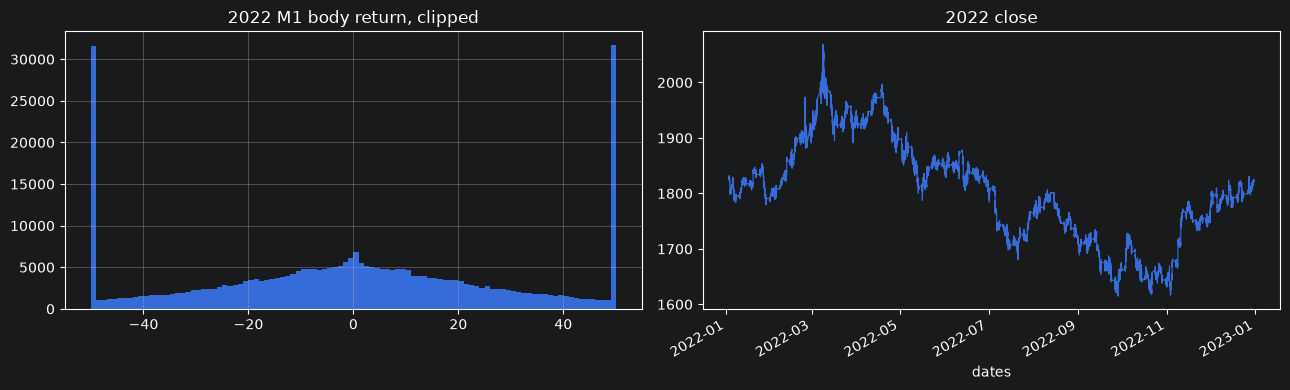

In [8]:
if len(raw_audit):
    first_year = int(raw_audit.iloc[0]["year"])
    raw_sample = load_year(first_year)
    if MAX_RAW_ROWS_PER_YEAR is not None and len(raw_sample) > MAX_RAW_ROWS_PER_YEAR:
        raw_sample = raw_sample.head(MAX_RAW_ROWS_PER_YEAR).copy()
    raw_sample["ret_points"] = (raw_sample[CLOSE] - raw_sample[OPEN]) * 100.0
    display(raw_sample.head())
    display(raw_sample[[OPEN, HIGH, LOW, CLOSE, "ret_points"]].describe(percentiles=[.01, .05, .5, .95, .99]).T)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    raw_sample["ret_points"].clip(-50, 50).hist(bins=100, ax=axes[0])
    axes[0].set_title(f"{first_year} M1 body return, clipped")
    raw_sample.set_index(DATE)[CLOSE].plot(ax=axes[1], linewidth=0.8)
    axes[1].set_title(f"{first_year} close")
    plt.tight_layout()
    plt.show()

## 4. Memory-safe yearly feature cache

In [9]:
def year_cache_path(year: int) -> Path:
    return NOTEBOOK_CACHE_DIR / f"features_labels_{year}.joblib"


def load_optional_year(year: int) -> pd.DataFrame | None:
    if not year_path(year).exists():
        return None
    return load_year(year)


def build_one_year_features_labels(year: int, force: bool = FORCE_YEAR_CACHE) -> pd.DataFrame:
    cache_path = year_cache_path(year)
    if cache_path.exists() and not force:
        print({"phase": "load_year_cache", "year": year, "path": str(cache_path)})
        return joblib.load(cache_path)

    print({"phase": "build_year_cache", "year": year, "path": str(cache_path)})
    parts: list[pd.DataFrame] = []

    prev_df = load_optional_year(year - 1)
    if prev_df is not None and not prev_df.empty:
        parts.append(prev_df.tail(YEAR_CACHE_WARMUP_ROWS))

    target_df = load_year(year)
    if MAX_RAW_ROWS_PER_YEAR is not None and len(target_df) > MAX_RAW_ROWS_PER_YEAR:
        target_df = target_df.head(MAX_RAW_ROWS_PER_YEAR).copy()
    parts.append(target_df)

    next_df = load_optional_year(year + 1)
    if next_df is not None and not next_df.empty:
        parts.append(next_df.head(int(CFG.label_max_forward) + NEXT_YEAR_LABEL_ROWS_PAD))

    raw = pd.concat(parts, ignore_index=True).sort_values(DATE).reset_index(drop=True)
    feat = build_features(raw)
    labeled = buy_labels_next_open(feat)
    labeled["year"] = pd.to_datetime(labeled[DATE]).dt.year.astype(int)
    out = labeled.loc[labeled["year"] == year].copy().reset_index(drop=True)

    joblib.dump(out, cache_path, compress=3)
    print({"phase": "saved_year_cache", "year": year, "rows": len(out), "cols": len(out.columns)})
    del parts, raw, feat, labeled, prev_df, target_df, next_df
    gc.collect()
    return out


def load_feature_frame(years: list[int], force: bool = FORCE_YEAR_CACHE) -> pd.DataFrame:
    frames = []
    for y in years:
        if not year_path(y).exists():
            print({"phase": "skip_missing_year", "year": y, "path": str(year_path(y))})
            continue
        frames.append(build_one_year_features_labels(y, force=force))
    if not frames:
        raise RuntimeError("No feature frames loaded. Check ML_TRADE_DATA_DIR and years.")
    frame = pd.concat(frames, ignore_index=True).sort_values(DATE).reset_index(drop=True)
    print({"phase": "feature_frame_ready", "years": years, "rows": len(frame), "cols": len(frame.columns)})
    return frame


frame = load_feature_frame(scope_years, force=FORCE_YEAR_CACHE)
frame.head()

{'phase': 'build_year_cache', 'year': 2022, 'path': 'D:\\ML_Trade_Bot\\research\\rf_mlflow\\cache\\research_features_notebook\\features_labels_2022.joblib'}
Loading year: 2021
Loading year: 2022
Loading year: 2023
{'phase': 'saved_year_cache', 'year': 2022, 'rows': 353204, 'cols': 492}
{'phase': 'build_year_cache', 'year': 2023, 'path': 'D:\\ML_Trade_Bot\\research\\rf_mlflow\\cache\\research_features_notebook\\features_labels_2023.joblib'}
Loading year: 2022
Loading year: 2023
Loading year: 2024
{'phase': 'saved_year_cache', 'year': 2023, 'rows': 351969, 'cols': 492}
{'phase': 'build_year_cache', 'year': 2024, 'path': 'D:\\ML_Trade_Bot\\research\\rf_mlflow\\cache\\research_features_notebook\\features_labels_2024.joblib'}
Loading year: 2023
Loading year: 2024
Loading year: 2025
{'phase': 'saved_year_cache', 'year': 2024, 'rows': 304535, 'cols': 492}
{'phase': 'feature_frame_ready', 'years': [2022, 2023, 2024], 'rows': 1009708, 'cols': 492}


,dates,open,low,high,close,tick_volume,ret_1,hl_range,upper_wick,lower_wick,body_abs,close_pos_range,atr14,close_diff_lag_1,body_lag_1,close_diff_lag_2,body_lag_2,close_diff_lag_3,body_lag_3,close_diff_lag_5,body_lag_5,close_diff_lag_8,body_lag_8,close_diff_lag_13,body_lag_13,close_diff_lag_21,body_lag_21,z_close_5,range_mean_5,body_mean_5,ret_sum_5,volatility_5,z_close_10,range_mean_10,body_mean_10,ret_sum_10,volatility_10,z_close_20,range_mean_20,body_mean_20,ret_sum_20,volatility_20,z_close_50,range_mean_50,body_mean_50,ret_sum_50,volatility_50,z_close_100,range_mean_100,body_mean_100,ret_sum_100,volatility_100,z_close_200,range_mean_200,body_mean_200,ret_sum_200,volatility_200,ema_dist_8,ema_slope_8,ema_dist_21,...,bb100_bb200_pos_diff,bb20_width_over_bb100,bb20_width_over_bb200,bb100_width_over_bb200,bb_lower_agree_20_100,bb_lower_agree_20_200,bb_lower_agree_all,bb_trend_context_buy,tod_sin,tod_cos,dow_sin,dow_cos,session_london_ny,session_ny,volume_z_100,m5_ret,m5_range,m5_ema_dist_8,m5_ema_slope_8,m5_ema_dist_21,m5_ema_slope_21,m5_ema_dist_55,m5_ema_slope_55,m5_rsi_14,m15_ret,m15_range,m15_ema_dist_8,m15_ema_slope_8,m15_ema_dist_21,m15_ema_slope_21,m15_ema_dist_55,m15_ema_slope_55,m15_rsi_14,h1_ret,h1_range,h1_ema_dist_8,h1_ema_slope_8,h1_ema_dist_21,h1_ema_slope_21,h1_ema_dist_55,h1_ema_slope_55,h1_rsi_14,h4_ret,h4_range,h4_ema_dist_8,h4_ema_slope_8,h4_ema_dist_21,h4_ema_slope_21,h4_ema_dist_55,h4_ema_slope_55,h4_rsi_14,sig_bb_reversion_buy,sig_pullback_trend_buy,sig_momentum_buy,buy_signal,label,label_res,entry_index,entry_price,year
0,2022-01-02 23:05:00,1830.615,1829.688,1830.684,1829.763,64,-85.2,99.6,6.9,7.5,85.2,0.075301,1.201074,8.2,5.0,-11.5,-10.0,-10.3,-8.1,9.1,9.5,7.2,6.6,-14.9,-14.8,1.0,0.9,1.788716,29.94,25.86,1371.2,632.762422,2.844653,21.29,17.50,1416.9,444.402891,4.243157,18.020,13.630,1397.0,314.709523,6.862615,17.178,11.558,1485.4,199.034185,9.607495,17.104,11.219,1457.0,141.270028,12.044570,18.4025,11.5120,1529.5,100.479880,1089.167860,311.190817,1274.768680,...,-0.609269,2.126711,2.697885,1.268572,0,0,0,1,-0.237686,0.971342,0.951057,0.309017,0,0,4.493491,-85.2,99.6,1095.839663,313.097047,1291.661916,129.166192,1451.801447,53.770424,91.108792,4.4,82.6,20.678151,5.908043,129.042897,12.90429,532.444881,19.720181,64.146245,65.1,165.2,254.910392,72.831541,711.769133,71.176913,945.45147,35.016721,68.684243,41.7,265.2,736.448639,210.413897,928.493996,92.8494,1405.083328,52.040123,61.207654,0,0,0,0,0.0,Lose,20001,1829.800,2022
1,2022-01-02 23:06:00,1829.800,1829.676,1830.199,1829.874,72,7.4,52.3,32.5,12.4,7.4,0.378585,1.152641,1406.0,-85.2,8.2,5.0,-11.5,-10.0,-21.2,-21.0,19.5,18.5,20.6,20.4,-5.7,-6.3,1.102585,36.20,23.14,1403.5,629.146712,1.906283,25.34,17.22,1418.0,444.366808,2.934961,20.060,13.425,1398.7,314.692566,4.848312,17.968,11.630,1491.5,199.020600,6.886509,17.479,11.178,1453.4,141.270453,9.177350,18.6135,11.5035,1531.6,100.480132,855.763891,244.503969,1168.971527,...,-0.572710,2.111591,2.833627,1.341939,0,0,0,1,-0.233445,0.972370,0.951057,0.309017,0,0,4.665851,-85.2,99.6,1095.839663,313.097047,1291.661916,129.166192,1451.801447,53.770424,91.108792,4.4,82.6,20.678151,5.908043,129.042897,12.90429,532.444881,19.720181,64.146245,65.1,165.2,254.910392,72.831541,711.769133,71.176913,945.45147,35.016721,68.684243,41.7,265.2,736.448639,210.413897,928.493996,92.8494,1405.083328,52.040123,61.207654,0,0,0,0,0.0,Lose,20002,1829.869,2022
2,2022-01-02 23:07:00,1829.869,1829.631,1829.970,1829.876,71,0.7,33.9,9.4,23.8,0.7,0.722714,1.094523,11.1,7.4,1406.0,-85.2,8.2,5.0,-10.3,-8.1,-0.1,-0.9,-4.4,-2.6,9.4,11.5,0.735216,41.22,21.66,1414.0,627.948951,1.454525,27.15,16.63,1411.0,444.607847,2.326589,21.050,13.105,1403.4,314.635805,3.921243,17.662,11.006,1520.0,198.891487,5.615152,17.704,11.100,1448.2,141.274806,7.668767,18.7365,11.4800,1539.9,100.475305,665.749693,190.214198,1062.883206,...,-0.513404,2.073498,2.837915,1.368661,0,0,0,1,-0.229200,0.973379,0.951057,0.309017,0,0,4.131376,-85.2,99.6,1095.839663,313.097047,12

## 5. Feature catalog and quality

Feature groups:

- Price action: body, wick, range, close position.
- Lag features: price/body changes at fixed lags.
- Rolling regime: z-score, volatility, rolling range/body stats.
- EMA trend: distance and slope.
- Bollinger behavior: position, width, squeeze/expansion, cross-band agreement.
- Overlay normalization: ATR/rank/cycle representation of overlay indicators.
- Time/session: minute-of-day, day-of-week, London/NY session.

In [10]:
all_feature_cols = feature_columns(frame)
feature_sets = named_feature_sets(frame)

feature_catalog = pd.DataFrame([
    {"feature_set": name, "n_features": len(cols), "sample_features": ", ".join(cols[:8])}
    for name, cols in feature_sets.items()
]).sort_values("feature_set")
display(feature_catalog)

feature_cols = feature_sets[FEATURE_SET_NAME]
print("Selected:", FEATURE_SET_NAME, "n_features:", len(feature_cols))

quality = pd.DataFrame({
    "dtype": frame[feature_cols].dtypes.astype(str),
    "missing_rate": frame[feature_cols].isna().mean(),
    "n_unique": frame[feature_cols].nunique(dropna=True),
}).sort_values(["missing_rate", "n_unique"], ascending=[False, True])
quality.head(30)

,feature_set,n_features,sample_features
0,fs01_price_action,10,"ret_1, hl_range, upper_wick, lower_wick, body_..."
1,fs02_lags_short,18,"ret_1, hl_range, close_diff_lag_1, body_lag_1,..."
2,fs03_lags_cycle,16,"close_diff_lag_5, body_lag_5, close_diff_lag_8..."
3,fs04_rolling_short,322,"close_diff_lag_5, body_lag_5, z_close_5, range..."
4,fs05_rolling_long,62,"z_close_50, range_mean_50, body_mean_50, ret_s..."
5,fs06_ema_trend,36,"ema_dist_8, ema_slope_8, ema_dist_21, ema_slop..."
6,fs07_bb_rsi_reversion,260,"lower_wick, close_pos_range, rsi_14, rsi_50, b..."
7,fs08_time_session,10,"tod_sin, tod_cos, dow_sin, dow_cos, session_lo..."
8,fs09_mtf_fast,274,"ret_1, rsi_14, bb20_mid, bb20_upper, bb20_lowe..."
9,fs10_mtf_full_all,481,"ret_1, hl_range, upper_wick, lower_wick, body_..."


Selected: fs14_bb_overlay_norm_behavior n_features: 325


,dtype,missing_rate,n_unique
bb_lower_agree_20_100,int64,0.0,2
bb_lower_agree_20_200,int64,0.0,2
bb_lower_agree_all,int64,0.0,2
bb_trend_context_buy,int64,0.0,2
sig_bb_reversion_buy,int64,0.0,2
sig_pullback_trend_buy,int64,0.0,2
sig_momentum_buy,int64,0.0,2
buy_signal,int64,0.0,2
dow_sin,float64,0.0,5
dow_cos,float64,0.0,6


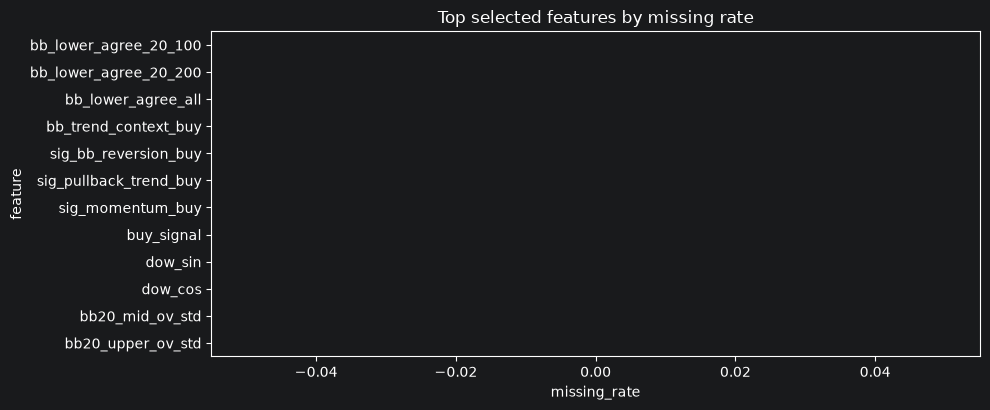

In [11]:
top_missing = quality.head(12).index.tolist()
if top_missing:
    fig, ax = plt.subplots(figsize=(10, max(3, len(top_missing) * 0.35)))
    sns.barplot(
        data=quality.loc[top_missing].reset_index().rename(columns={"index": "feature"}),
        x="missing_rate",
        y="feature",
        ax=ax,
    )
    ax.set_title("Top selected features by missing rate")
    plt.tight_layout()
    plt.show()

## 6. Label and Buy candidate universe

Label contract:

- At candle `t`, Buy entry tại `open[t+1]`.
- TP = `entry + r1 * rr`; SL = `entry - r1`.
- `label = 1` nếu TP chạm trước; `label = 0` nếu SL chạm trước.
- `label = NaN` nếu không resolve trong `label_max_forward` M1 rows.
- Feature chỉ dùng thông tin biết tại close của candle `t`; label mới nhìn tương lai.

Model dự đoán trên universe `buy_signal == 1`, không dự đoán mọi candle.

In [12]:
def candidate_mask(data: pd.DataFrame, cols: list[str]) -> pd.Series:
    return (data["buy_signal"] == 1) & data["label"].notna() & data[cols].notna().all(axis=1)


label_audit = frame.groupby("year", as_index=False).agg(
    rows=(DATE, "size"),
    buy_candidates=("buy_signal", "sum"),
    resolved=("label", lambda s: int(s.notna().sum())),
    wins=("label", lambda s: int((s == 1).sum())),
    losses=("label", lambda s: int((s == 0).sum())),
)
label_audit["resolved_wr_pct"] = (label_audit["wins"] * 100 / label_audit["resolved"].replace(0, np.nan)).round(4)

cand = frame.loc[candidate_mask(frame, feature_cols), [DATE, "year", "label", "buy_signal", *feature_cols]].copy()
candidate_audit = cand.groupby("year", as_index=False).agg(candidates=("label", "size"), wins=("label", "sum"))
candidate_audit["candidate_wr_pct"] = (candidate_audit["wins"] * 100 / candidate_audit["candidates"].replace(0, np.nan)).round(4)

display(label_audit)
display(candidate_audit)
print("Candidate rows:", len(cand))

,year,rows,buy_candidates,resolved,wins,losses,resolved_wr_pct
0,2022,353204,148967,352101,171242,180859,48.6343
1,2023,351969,147350,346690,172971,173719,49.8921
2,2024,304535,127818,303841,163713,140128,53.8811


,year,candidates,wins,candidate_wr_pct
0,2022,148526,72019.0,48.4892
1,2023,145265,72520.0,49.9226
2,2024,127588,68962.0,54.0505


Candidate rows: 421379


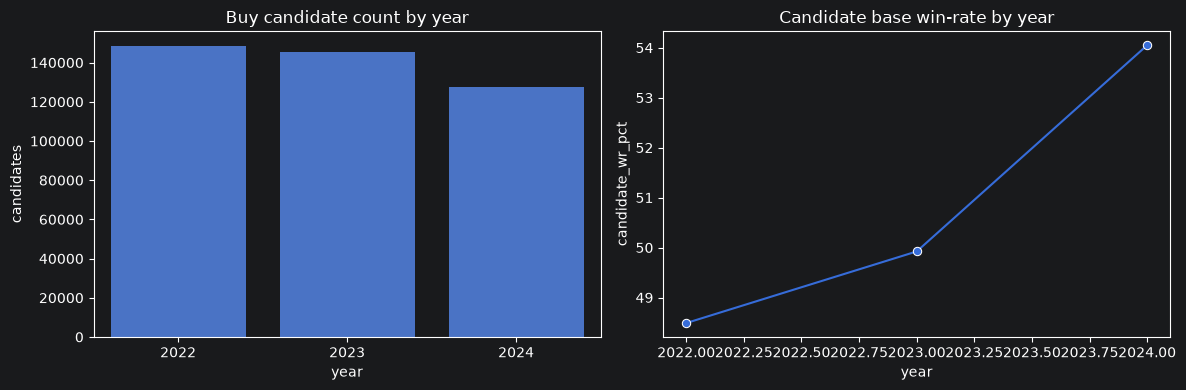

In [13]:
if len(candidate_audit):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=candidate_audit, x="year", y="candidates", ax=axes[0])
    axes[0].set_title("Buy candidate count by year")
    sns.lineplot(data=candidate_audit, x="year", y="candidate_wr_pct", marker="o", ax=axes[1])
    axes[1].set_title("Candidate base win-rate by year")
    plt.tight_layout()
    plt.show()

## 7. Time split and leakage checks

In [14]:
def split_candidates(candidates: pd.DataFrame):
    train = candidates[candidates["year"].isin(CFG.split.train_years)].copy()
    valid = candidates[candidates["year"].isin(CFG.split.valid_years)].copy()
    test = candidates[candidates["year"].isin(CFG.split.test_years)].copy()
    return train, valid, test


train_df, valid_df, test_df = split_candidates(cand)
split_audit = pd.DataFrame([
    {"split": "train", "years": CFG.split.train_years, "rows": len(train_df), "win_rate_pct": train_df["label"].mean() * 100 if len(train_df) else np.nan},
    {"split": "valid", "years": CFG.split.valid_years, "rows": len(valid_df), "win_rate_pct": valid_df["label"].mean() * 100 if len(valid_df) else np.nan},
    {"split": "test", "years": CFG.split.test_years, "rows": len(test_df), "win_rate_pct": test_df["label"].mean() * 100 if len(test_df) else np.nan},
])
display(split_audit)

forbidden = {"label", "label_res", "entry_index", "entry_price"}
leakage_cols = sorted(set(feature_cols) & forbidden)
future_name_suspects = [c for c in feature_cols if any(t in c.lower() for t in ["future", "next", "target", "label", "entry"])]
checks = {
    "no_forbidden_columns_in_features": len(leakage_cols) == 0,
    "no_future_name_suspects": len(future_name_suspects) == 0,
    "train_before_valid": train_df[DATE].max() < valid_df[DATE].min() if len(train_df) and len(valid_df) else None,
    "valid_before_test": valid_df[DATE].max() < test_df[DATE].min() if len(valid_df) and len(test_df) else None,
}
print(json.dumps(checks, indent=2, default=str))
print("leakage_cols:", leakage_cols)
print("future_name_suspects:", future_name_suspects[:20])

,split,years,rows,win_rate_pct
0,train,"(2018, 2019, 2020, 2021, 2022)",148526,48.489153
1,valid,"(2023,)",145265,49.922555
2,test,"(2024, 2025, 2026)",127588,54.050538


{
  "no_forbidden_columns_in_features": true,
  "no_future_name_suspects": true,
  "train_before_valid": true,
  "valid_before_test": true
}
leakage_cols: []
future_name_suspects: []


## 8. Baseline probability model

In [15]:
def cap_train_rows(df: pd.DataFrame, max_rows: int | None, seed: int) -> pd.DataFrame:
    if max_rows is None or len(df) <= max_rows:
        return df
    per_class = max_rows // 2
    return (
        df.groupby("label", group_keys=False)
        .apply(lambda g: g.sample(min(len(g), per_class), random_state=seed))
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )


train_fit_df = cap_train_rows(train_df, MAX_TRAIN_ROWS, RANDOM_STATE)
x_train_raw = train_fit_df[feature_cols].to_numpy(dtype=float)
y_train = train_fit_df["label"].astype(int).to_numpy()
x_valid_raw = valid_df[feature_cols].to_numpy(dtype=float)
y_valid = valid_df["label"].astype(int).to_numpy()
x_test_raw = test_df[feature_cols].to_numpy(dtype=float)
y_test = test_df["label"].astype(int).to_numpy()

scaler = RobustClipScaler().fit(x_train_raw)
x_train = scaler.transform(x_train_raw)
x_valid = scaler.transform(x_valid_raw) if len(valid_df) else np.empty((0, len(feature_cols)))
x_test = scaler.transform(x_test_raw) if len(test_df) else np.empty((0, len(feature_cols)))

print({"x_train": x_train.shape, "x_valid": x_valid.shape, "x_test": x_test.shape})

{'x_train': (148526, 326), 'x_valid': (145265, 326), 'x_test': (127588, 326)}


In [16]:
def make_model(kind: str):
    if kind == "lightgbm":
        if LGBMClassifier is None:
            raise RuntimeError("lightgbm is not installed. Set MODEL_KIND='random_forest'.")
        return LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            min_child_samples=300,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if kind == "random_forest":
        return RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=300,
            min_samples_split=800,
            max_features="sqrt",
            max_samples=0.8,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            bootstrap=True,
        )
    raise ValueError(kind)


if len(y_train) == 0:
    raise RuntimeError("Train split is empty. Use RUN_FULL_RESEARCH=True or include train years in FAST_YEARS.")

model = make_model(MODEL_KIND)
started = time.time()
model.fit(x_train, y_train)
print({"phase": "model_fit_done", "model_kind": MODEL_KIND, "elapsed_sec": round(time.time() - started, 2)})

[LightGBM] [Info] Number of positive: 72019, number of negative: 76507
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.083166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 80326
[LightGBM] [Info] Number of data points in the train set: 148526, number of used features: 324
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.484892 -> initscore=-0.060452
[LightGBM] [Info] Start training from score -0.060452
{'phase': 'model_fit_done', 'model_kind': 'lightgbm', 'elapsed_sec': 8.47}


In [17]:
def predict_p(model, x: np.ndarray) -> np.ndarray:
    return model.predict_proba(x)[:, 1] if len(x) else np.array([], dtype=float)


def probability_metrics(y: np.ndarray, p: np.ndarray, threshold: float = 0.5) -> dict:
    if len(y) == 0:
        return {"rows": 0}
    pred = (p >= threshold).astype(int)
    out = {
        "rows": int(len(y)),
        "positive_rate": float(np.mean(y)),
        "pred_positive_rate": float(np.mean(pred)),
        "accuracy_at_0_5": float(accuracy_score(y, pred)),
        "brier": float(brier_score_loss(y, p)),
        "logloss": float(log_loss(y, p, labels=[0, 1])),
        "avg_precision": float(average_precision_score(y, p)),
    }
    if len(np.unique(y)) == 2:
        out["auc"] = float(roc_auc_score(y, p))
    return out


p_train = predict_p(model, x_train)
p_valid = predict_p(model, x_valid)
p_test = predict_p(model, x_test)
metrics = {
    "train": probability_metrics(y_train, p_train),
    "valid": probability_metrics(y_valid, p_valid),
    "test": probability_metrics(y_test, p_test),
}
pd.DataFrame(metrics).T

,rows,positive_rate,pred_positive_rate,accuracy_at_0_5,brier,logloss,avg_precision,auc
train,148526.0,0.484892,0.461306,0.862644,0.163822,0.511754,0.935130,0.937804
valid,145265.0,0.499226,0.447121,0.490566,0.265247,0.726535,0.496630,0.488243
test,127588.0,0.540505,0.385710,0.495893,0.265783,0.728434,0.543764,0.510802


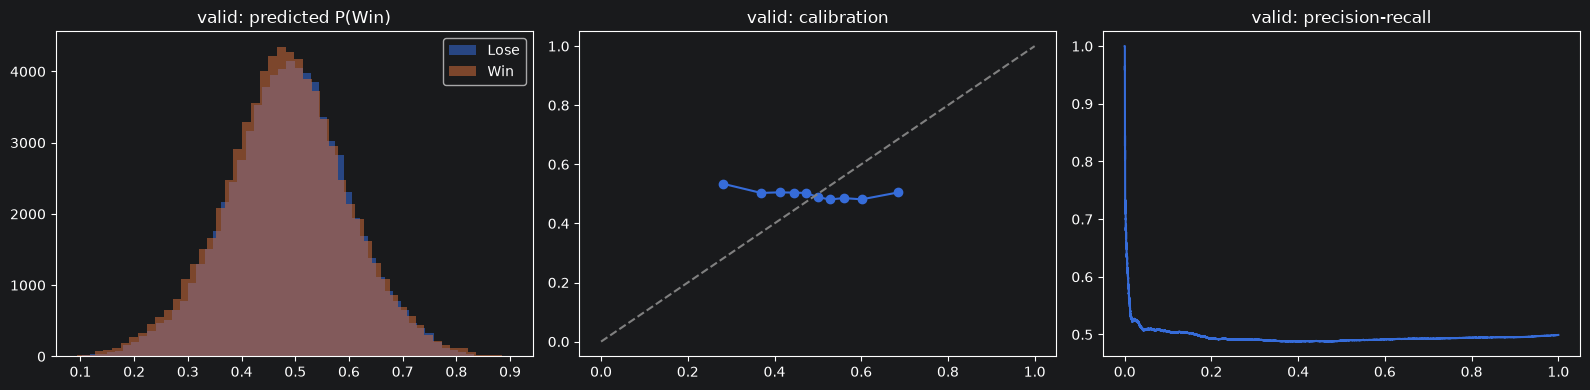

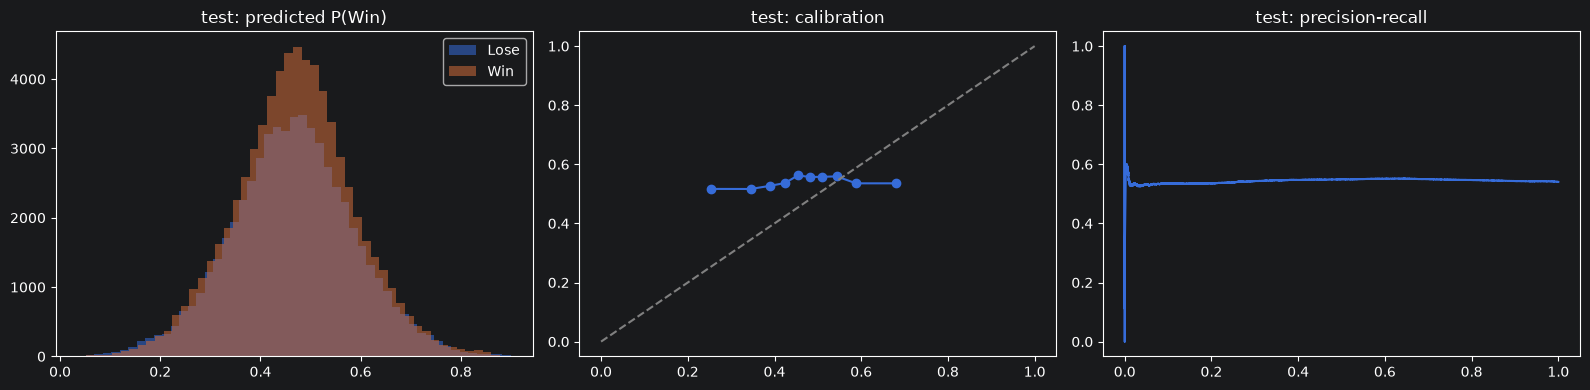

In [18]:
def plot_probability_diagnostics(y: np.ndarray, p: np.ndarray, split_name: str):
    if len(y) == 0:
        print(f"Skip {split_name}: empty split")
        return
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(p[y == 0], bins=50, alpha=0.55, label="Lose")
    axes[0].hist(p[y == 1], bins=50, alpha=0.55, label="Win")
    axes[0].set_title(f"{split_name}: predicted P(Win)")
    axes[0].legend()

    frac_pos, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
    axes[1].plot(mean_pred, frac_pos, marker="o")
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_title(f"{split_name}: calibration")

    precision, recall, _ = precision_recall_curve(y, p)
    axes[2].plot(recall, precision)
    axes[2].set_title(f"{split_name}: precision-recall")
    plt.tight_layout()
    plt.show()


plot_probability_diagnostics(y_valid, p_valid, "valid")
plot_probability_diagnostics(y_test, p_test, "test")

## 9. Threshold research

In [19]:
def threshold_table(df: pd.DataFrame, p: np.ndarray, thresholds: tuple[float, ...] = CFG.threshold_grid) -> pd.DataFrame:
    rows = []
    if len(df) == 0:
        return pd.DataFrame(rows)
    y = df["label"].astype(int).to_numpy()
    years = sorted(df["year"].unique())
    for t in thresholds:
        selected = p >= t
        for year in years:
            ym = df["year"].to_numpy() == year
            m = selected & ym
            wins = int(np.count_nonzero(m & (y == 1)))
            losses = int(np.count_nonzero(m & (y == 0)))
            resolved = wins + losses
            rows.append({"threshold": float(t), "year": int(year), "resolved": resolved, "wins": wins, "losses": losses, "winrate": round(wins * 100 / resolved, 4) if resolved else 0.0})
    return pd.DataFrame(rows)


def select_threshold(valid_curve: pd.DataFrame, min_deals: int = 2_200) -> float:
    grouped = valid_curve.groupby("threshold", as_index=False).agg(resolved=("resolved", "sum"), wins=("wins", "sum"), min_year_deals=("resolved", "min"))
    grouped["winrate"] = grouped["wins"] * 100 / grouped["resolved"].replace(0, np.nan)
    grouped["deal_penalty"] = (grouped["resolved"] - 3000).abs() / 3000
    grouped["score"] = grouped["winrate"] - 3.0 * grouped["deal_penalty"]
    viable = grouped[grouped["resolved"] >= min_deals].copy()
    if viable.empty:
        viable = grouped.copy()
    display(grouped.sort_values("threshold"))
    return float(viable.sort_values(["score", "winrate", "resolved"], ascending=[False, False, False]).iloc[0]["threshold"])


valid_curve = threshold_table(valid_df, p_valid)
test_curve = threshold_table(test_df, p_test)
selected_threshold = select_threshold(valid_curve) if len(valid_curve) else 0.5
print("selected_threshold:", selected_threshold)
display(test_curve[test_curve["threshold"] == selected_threshold] if len(test_curve) else test_curve)

,threshold,resolved,wins,min_year_deals,winrate,deal_penalty,score
0,0.50,64951,31734,64951,48.858370,20.650333,-13.092630
1,0.51,59669,29106,59669,48.779098,18.889667,-7.889902
2,0.52,54481,26610,54481,48.842716,17.160333,-2.638284
3,0.53,49520,24233,49520,48.935784,15.506667,2.415784
4,0.54,44682,21932,44682,49.084643,13.894000,7.402643
5,0.55,40050,19661,40050,49.091136,12.350000,12.041136
6,0.56,35831,17603,35831,49.127850,10.943667,16.296850
7,0.57,31844,15669,31844,49.205502,9.614667,20.361502
8,0.58,28233,13948,28233,49.403181,8.411000,24.170181
9,0.59,24831,12368,24831,49.808707,7.277000,27.977707


selected_threshold: 0.6


,threshold,year,resolved,wins,losses,winrate
10,0.6,2024,16218,8674,7544,53.4838


## 10. Feature importance

In [20]:
def feature_importance_frame(model, cols: list[str]) -> pd.DataFrame:
    importance = model.feature_importances_ if hasattr(model, "feature_importances_") else np.zeros(len(cols))
    return pd.DataFrame({"feature": cols, "importance": importance}).sort_values("importance", ascending=False)


importance = feature_importance_frame(model, feature_cols)
display(importance.head(30))
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=importance.head(25), x="importance", y="feature", ax=ax)
ax.set_title(f"Top feature importance - {MODEL_KIND}")
plt.tight_layout()
plt.show()

ValueError: All arrays must be of the same length

In [22]:
# Optional SHAP: bật khi cần giải thích sâu, có thể tốn thời gian.
RUN_SHAP = True
SHAP_ROWS = 2_000

if RUN_SHAP:
    import shap

    sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(x_valid), size=min(SHAP_ROWS, len(x_valid)), replace=False)
    shap_x = pd.DataFrame(x_valid[sample_idx], columns=feature_cols)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(shap_x)
    values = shap_values[1] if isinstance(shap_values, list) and len(shap_values) > 1 else shap_values
    if getattr(values, "ndim", 0) == 3:
        values = values[:, :, 1]
    shap.summary_plot(values, shap_x, max_display=25)

D:\ML_Trade_Bot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: Shape of passed values is (2000, 326), indices imply (2000, 325)

## 11. Save artifacts and optional MLflow

In [23]:
def json_safe(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if is_dataclass(obj):
        return asdict(obj)
    raise TypeError(type(obj).__name__)


run_id = int(time.time())
summary = {
    "run_id": run_id,
    "mode": "full" if RUN_FULL_RESEARCH else "fast",
    "years": scope_years,
    "feature_set": FEATURE_SET_NAME,
    "n_features": len(feature_cols),
    "model_kind": MODEL_KIND,
    "max_train_rows": MAX_TRAIN_ROWS,
    "selected_threshold": selected_threshold,
    "metrics": metrics,
    "split_audit": split_audit.to_dict(orient="records"),
    "candidate_audit": candidate_audit.to_dict(orient="records"),
    "trade_config": CFG.trade,
    "label_max_forward": CFG.label_max_forward,
}

if SAVE_ARTIFACTS:
    run_dir = NOTEBOOK_ARTIFACT_DIR / f"run_{run_id}_{MODEL_KIND}_{FEATURE_SET_NAME}"
    run_dir.mkdir(parents=True, exist_ok=True)
    (run_dir / "summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2, default=json_safe), encoding="utf-8")
    pd.DataFrame(metrics).T.to_csv(run_dir / "metrics.csv", encoding="utf-8-sig")
    split_audit.to_csv(run_dir / "split_audit.csv", index=False, encoding="utf-8-sig")
    label_audit.to_csv(run_dir / "label_audit.csv", index=False, encoding="utf-8-sig")
    candidate_audit.to_csv(run_dir / "candidate_audit.csv", index=False, encoding="utf-8-sig")
    quality.to_csv(run_dir / "feature_quality.csv", encoding="utf-8-sig")
    importance.to_csv(run_dir / "feature_importance.csv", index=False, encoding="utf-8-sig")
    valid_curve.to_csv(run_dir / "threshold_valid.csv", index=False, encoding="utf-8-sig")
    test_curve.to_csv(run_dir / "threshold_test.csv", index=False, encoding="utf-8-sig")
    (run_dir / "feature_columns.json").write_text(json.dumps(feature_cols, ensure_ascii=False, indent=2), encoding="utf-8")
    joblib.dump({"model": model, "scaler": scaler, "feature_columns": feature_cols, "selected_threshold": selected_threshold, "metrics": metrics}, run_dir / "model_bundle.joblib", compress=3)
    print("Saved:", run_dir)
else:
    print(json.dumps(summary, ensure_ascii=False, indent=2, default=json_safe))

NameError: name 'importance' is not defined

In [ ]:
if ENABLE_MLFLOW:
    import mlflow

    mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", f"sqlite:///{REPO_ROOT / 'mlflow.db'}"))
    mlflow.set_experiment(CFG.experiment_name)
    with mlflow.start_run(run_name=f"notebook_research_features_{run_id}"):
        mlflow.log_param("feature_set", FEATURE_SET_NAME)
        mlflow.log_param("model_kind", MODEL_KIND)
        mlflow.log_param("n_features", len(feature_cols))
        mlflow.log_param("selected_threshold", selected_threshold)
        for split, values in metrics.items():
            for key, value in values.items():
                if isinstance(value, (int, float)):
                    mlflow.log_metric(f"{split}_{key}", float(value))
        if SAVE_ARTIFACTS:
            for artifact in run_dir.iterdir():
                mlflow.log_artifact(str(artifact))
    print("MLflow logged")

## 12. Research conclusion checklist

Ghi kết luận sau mỗi run:

1. Data quality: năm nào thiếu/gap/duplicate đáng chú ý?
2. Label: base win-rate theo năm có ổn định không?
3. Candidate universe: số Buy candidate mỗi năm có đủ không?
4. Feature: nhóm nào missing nhiều hoặc drift mạnh?
5. Model: valid/test AUC, Brier, LogLoss có tốt hơn baseline base-rate không?
6. Threshold: threshold chọn trên valid có giữ được resolved deals và win-rate trên test không?
7. Next experiment: feature set/model/label rule nào cần thử tiếp?

Quy tắc đọc kết quả:

- Valid tốt nhưng test rơi mạnh: kiểm tra regime shift hoặc overfit threshold.
- AUC quanh 0.50 nhưng calibration ổn: model chỉ phù hợp làm risk filter nhẹ.
- Calibration lệch: ưu tiên calibration/objective/logloss trước khi tối ưu threshold.
- Feature importance bị time/session chi phối: phân tích riêng theo session.